Para analizar:
- Mejor valorados
- Tiempo de estancia
- Precios
- Zonas
- Número de reviews
- Puntución de la casa
- Diferencias de precios por tipo de habitación


In [1]:
import  pandas as pd

raw_data = pd.read_csv('/content/sample_data/AB_NYC_2019.csv', on_bad_lines='skip')
raw_data

,id,name,host_id,host_name,neighbourhood_group,neighbourhood,latitude,longitude,room_type,price,minimum_nights,number_of_reviews,last_review,reviews_per_month,calculated_host_listings_count,availability_365
0,2539,Clean & quiet apt home by the park,2787,John,Brooklyn,Kensington,40.64749,-73.97237,Private room,149,1,9,2018-10-19,0.21,6,365
1,2595,Skylit Midtown Castle,2845,Jennifer,Manhattan,Midtown,40.75362,-73.98377,Entire home/apt,225,1,45,2019-05-21,0.38,2,355
2,3647,THE VILLAGE OF HARLEM....NEW YORK !,4632,Elisabeth,Manhattan,Harlem,40.80902,-73.94190,Private room,150,3,0,NaN,NaN,1,365
3,3831,Cozy Entire Floor of Brownstone,4869,LisaRoxanne,Brooklyn,Clinton Hill,40.68514,-73.95976,Entire home/apt,89,1,270,2019-07-05,4.64,1,194
4,5022,Entire Apt: Spacious Studio/Loft by central park,7192,Laura,Manhattan,East Harlem,40.79851,-73.94399,Entire home/apt,80,10,9,2018-11-19,0.10,1,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
48890,36484665,Charming one bedroom - newly renovated rowhouse,8232441,Sabrina,Brooklyn,Bedford-Stuyvesant,40.67853,-73.94995,Private room,70,2,0,NaN,NaN,2,9
48891,36485057,Affordable room in Bushwick/East Williamsburg,6570630,Marisol,Brooklyn,Bushwick,40.70184,-73.93317,Private room,40,4,0,NaN,NaN,2,36
48892,36485431,Sunny Studio at Historical Neighborhood,23492952,Ilgar & Aysel,Manhattan,Harlem,40.81475,-73.94867,Entire home/apt,115,10,0,NaN,NaN,1,27
48893,36485609,43rd St. Time Square-cozy single bed,30985759,Taz,Manhattan,Hell's Kitchen,40.75751,-73.99112,Shared room,55,1,0,NaN,NaN,6,2


In [2]:
# CUENTA LOS VALORES FALTANTES
raw_data.isna().sum().sum()


np.int64(20141)

In [3]:
raw_data.isna().sum()


,0
id,0
name,16
host_id,0
host_name,21
neighbourhood_group,0
neighbourhood,0
latitude,0
longitude,0
room_type,0
price,0


In [4]:
# ESTE CÓDIGO CALCULA EL PORCENTAJE DE VALORES RESTANTES POR CADA COLUMNA
(raw_data.isna().sum() / len(raw_data) * 100).sort_values(ascending=False)

,0
last_review,20.558339
reviews_per_month,20.558339
host_name,0.042949
name,0.032723
neighbourhood_group,0.000000
neighbourhood,0.000000
id,0.000000
host_id,0.000000
longitude,0.000000
latitude,0.000000


In [5]:
# EN ESTE CÓDIGO VERIFICAMOS VALORES DUPLICADOS EN LA COLUMNA id
raw_data[raw_data['id'].duplicated() == True]
raw_data['id'].value_counts()



,count
id,
36487245,1
2539,1
2595,1
3647,1
3831,1
...,...
7750,1
7726,1
7322,1


In [6]:
# EN ESTE CÓDIGO ELIMINAMOS LOS VALORES DUPLICADOS DE LA COLUMNA id
raw_data = raw_data.drop_duplicates(subset=raw_data.columns.difference(['id']))
print(raw_data.shape)
raw_data.head()

(48895, 16)


,id,name,host_id,host_name,neighbourhood_group,neighbourhood,latitude,longitude,room_type,price,minimum_nights,number_of_reviews,last_review,reviews_per_month,calculated_host_listings_count,availability_365
0,2539,Clean & quiet apt home by the park,2787,John,Brooklyn,Kensington,40.64749,-73.97237,Private room,149,1,9,2018-10-19,0.21,6,365
1,2595,Skylit Midtown Castle,2845,Jennifer,Manhattan,Midtown,40.75362,-73.98377,Entire home/apt,225,1,45,2019-05-21,0.38,2,355
2,3647,THE VILLAGE OF HARLEM....NEW YORK !,4632,Elisabeth,Manhattan,Harlem,40.80902,-73.94190,Private room,150,3,0,NaN,NaN,1,365
3,3831,Cozy Entire Floor of Brownstone,4869,LisaRoxanne,Brooklyn,Clinton Hill,40.68514,-73.95976,Entire home/apt,89,1,270,2019-07-05,4.64,1,194
4,5022,Entire Apt: Spacious Studio/Loft by central park,7192,Laura,Manhattan,East Harlem,40.79851,-73.94399,Entire home/apt,80,10,9,2018-11-19,0.10,1,0


In [7]:
raw_data.select_dtypes(include=['object']).columns

Index(['name', 'host_name', 'neighbourhood_group', 'neighbourhood',
       'room_type', 'last_review'],
      dtype='object')

Text(0, 0.5, 'Sample Number')

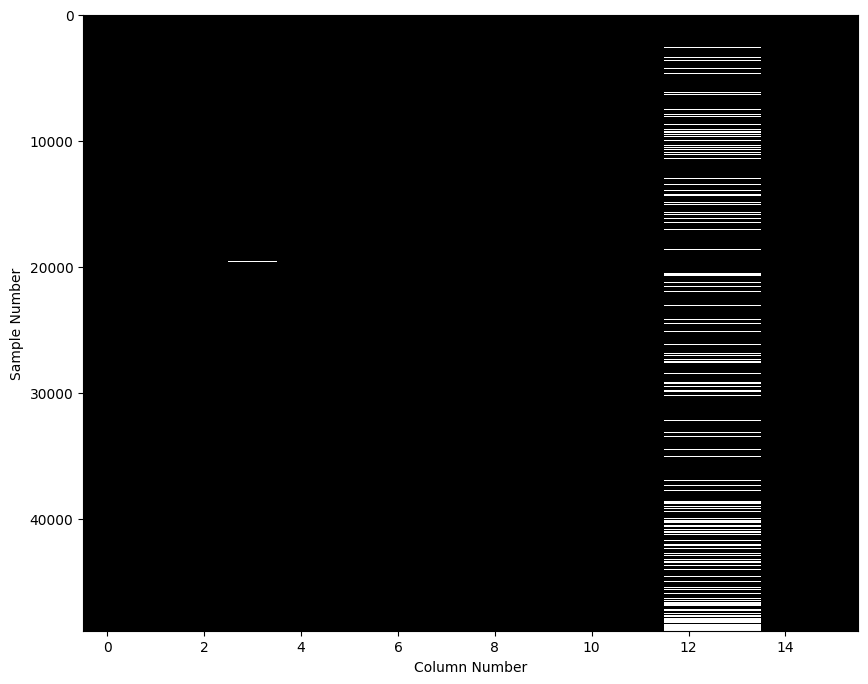

In [8]:
import matplotlib.pyplot as plt
plt.figure(figsize=(10, 8))
plt.imshow(raw_data.isna(), aspect="auto", interpolation="nearest", cmap="gray")
plt.xlabel("Column Number")
plt.ylabel("Sample Number")

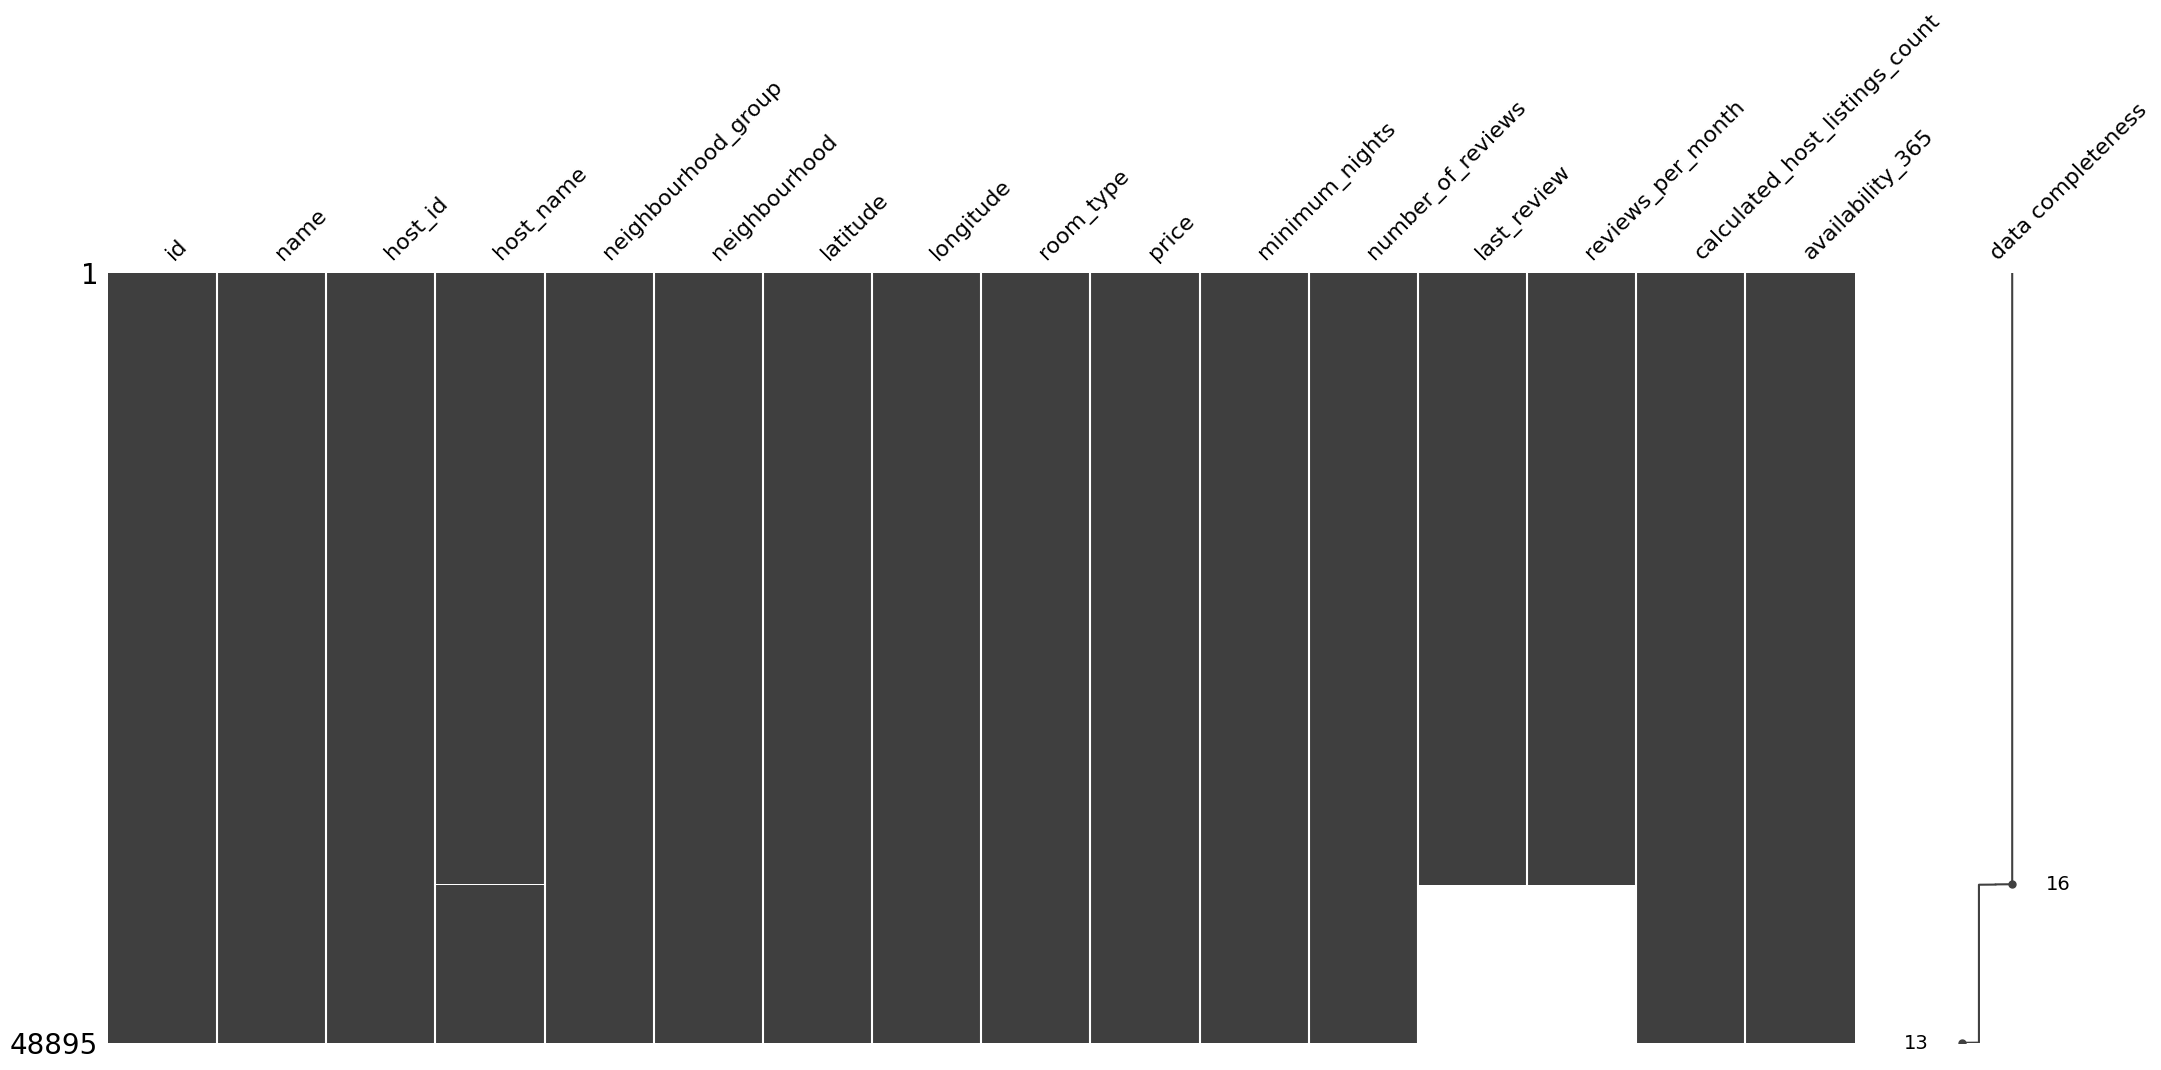

In [9]:
# LISTA DE VALORES NULOS
import missingno as msno
msno.matrix(raw_data, labels=True, sort="descending");

In [10]:
# LISTA DE COLUMNAS
raw_data.columns

Index(['id', 'name', 'host_id', 'host_name', 'neighbourhood_group',
       'neighbourhood', 'latitude', 'longitude', 'room_type', 'price',
       'minimum_nights', 'number_of_reviews', 'last_review',
       'reviews_per_month', 'calculated_host_listings_count',
       'availability_365'],
      dtype='object')

In [11]:
# VEMOS LOS 5 BARRIOS DE NYC
raw_data['neighbourhood_group'].unique()

array(['Brooklyn', 'Manhattan', 'Queens', 'Staten Island', 'Bronx'],
      dtype=object)

<Axes: xlabel='neighbourhood_group', ylabel='count'>

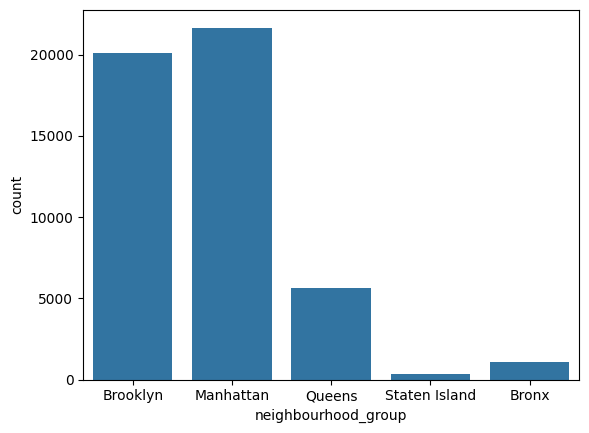

In [12]:
# EN ESTE GRÁFICO QUIERO VER LA DIFERENCIA DE AIRBNB QUE HAY ENTRE LOS 5 BARRIOS DE NYC
import seaborn as sns
sns.countplot(data = raw_data, x = 'neighbourhood_group')

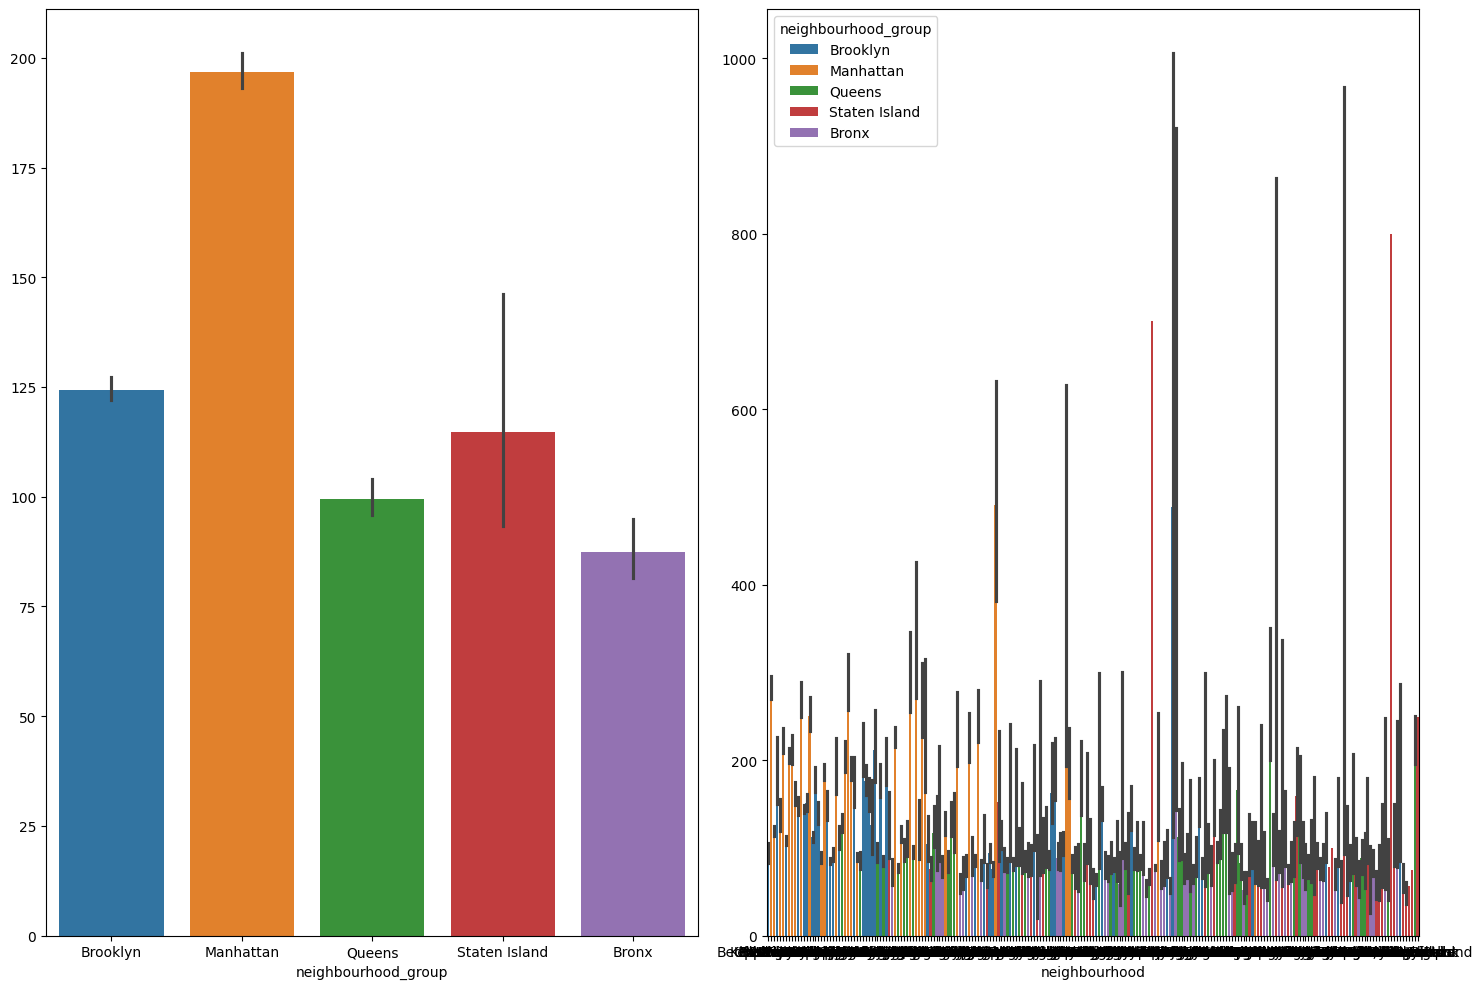

In [13]:
# EN ESTOS HISTOGRAMAS VEMOS LAS DIFERENCIAS DE PRECIOS MEDIA ENTRE LOS AIRBNB DE LOS DIFERENTES BARRIOS,
# PRIMERA PARTE ÚTIL, SEGUNDA NO ES MUY LEGIBLE
# HACER EL SEGUNDO GRÁFICO CON LOS BARRIOS DENTRO DE LOS GRUPOS DE BARRIOS (TODOS LOS BARRIOS DE Brooklyn DENTRO DE Brooklyn...)
fig, axis = plt.subplots(ncols=2, figsize=(15, 10))
sns.barplot(ax=axis[0],data=raw_data, x= "neighbourhood_group", y="price",hue="neighbourhood_group").set(ylabel=None)
sns.barplot(ax=axis[1],data=raw_data, x= "neighbourhood", y="price",hue="neighbourhood_group").set(ylabel=None)

plt.tight_layout()
plt.show()

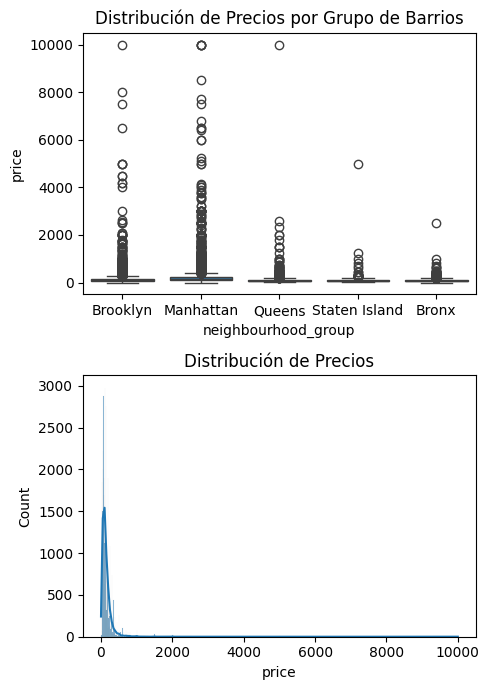

In [14]:
#GENERAMOS HISTOGRAMAS
import matplotlib.pyplot as plt
import seaborn as sns

fig, axis = plt.subplots(2, 1, figsize=(5, 7))

# CREAMOS UN DIAGRAMA DE CAJAS PARA VISUALIZAR LA DISTRIBUCIÓN DEL PRECIO POR GRUPO DE BARRIOS
sns.boxplot(ax=axis[0], data=raw_data, x="neighbourhood_group", y="price")
axis[0].set_title("Distribución de Precios por Grupo de Barrios")

# CREAMOS UN HISTOGRAMA PARA LA DISTRIBUCIÓN GENERAL DE LOS PRECIOS
sns.histplot(ax=axis[1], data=raw_data, x="price", kde=True)
axis[1].set_title("Distribución de Precios")

plt.tight_layout()
plt.show()

In [15]:
import pandas as pd
raw_data = pd.read_csv('/content/sample_data/AB_NYC_2019.csv', on_bad_lines='skip')
sorted_data = raw_data.sort_values(by='last_review', ascending=True)
sorted_data


,id,name,host_id,host_name,neighbourhood_group,neighbourhood,latitude,longitude,room_type,price,minimum_nights,number_of_reviews,last_review,reviews_per_month,calculated_host_listings_count,availability_365
317,74860,"Sunlit and Cozy Williamsburg/Greenpoint, Brooklyn",394752,Allison,Brooklyn,Greenpoint,40.72488,-73.95018,Private room,55,2,1,2011-03-28,0.01,1,0
163,40039,Luxurious Condo in DUBMO with View,171851,Henry,Brooklyn,DUMBO,40.70207,-73.98571,Private room,250,3,14,2011-04-25,0.13,1,189
330,81739,Loft w/ Terrace @ Box House Hotel,417504,The Box House Hotel,Brooklyn,Greenpoint,40.73842,-73.95312,Private room,249,3,2,2011-05-12,0.02,28,60
125,28396,Modern Apt with Spectacular Views,6197784,Jo,Brooklyn,Williamsburg,40.71923,-73.96468,Private room,90,1,9,2011-09-18,0.08,1,245
143,32363,Fully Furnished Basement Apartment,140025,Fredah,Queens,Flushing,40.74028,-73.83168,Private room,140,2,1,2011-09-19,0.01,1,1
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
48890,36484665,Charming one bedroom - newly renovated rowhouse,8232441,Sabrina,Brooklyn,Bedford-Stuyvesant,40.67853,-73.94995,Private room,70,2,0,NaN,NaN,2,9
48891,36485057,Affordable room in Bushwick/East Williamsburg,6570630,Marisol,Brooklyn,Bushwick,40.70184,-73.93317,Private room,40,4,0,NaN,NaN,2,36
48892,36485431,Sunny Studio at Historical Neighborhood,23492952,Ilgar & Aysel,Manhattan,Harlem,40.81475,-73.94867,Entire home/apt,115,10,0,NaN,NaN,1,27
48893,36485609,43rd St. Time Square-cozy single bed,30985759,Taz,Manhattan,Hell's Kitchen,40.75751,-73.99112,Shared room,55,1,0,NaN,NaN,6,2


In [16]:
#AQUÍ VEMOS LOS APARTAMENTOS QUE MAS REVIEW TIENEN, EN CONSECUENCIA, LOS MÁS USADOS/DEMANDADDOS (QUITO LOS Nan DE reviews_per_month Y de number_of_reviews)
raw_data = pd.read_csv('/content/sample_data/AB_NYC_2019.csv', on_bad_lines='skip')
review_data = raw_data.dropna(subset=['reviews_per_month', 'number_of_reviews'])
review_data = review_data.sort_values(by='number_of_reviews', ascending=False)
review_data.head()

,id,name,host_id,host_name,neighbourhood_group,neighbourhood,latitude,longitude,room_type,price,minimum_nights,number_of_reviews,last_review,reviews_per_month,calculated_host_listings_count,availability_365
11759,9145202,Room near JFK Queen Bed,47621202,Dona,Queens,Jamaica,40.66730,-73.76831,Private room,47,1,629,2019-07-05,14.58,2,333
2031,903972,Great Bedroom in Manhattan,4734398,Jj,Manhattan,Harlem,40.82085,-73.94025,Private room,49,1,607,2019-06-21,7.75,3,293
2030,903947,Beautiful Bedroom in Manhattan,4734398,Jj,Manhattan,Harlem,40.82124,-73.93838,Private room,49,1,597,2019-06-23,7.72,3,342
2015,891117,Private Bedroom in Manhattan,4734398,Jj,Manhattan,Harlem,40.82264,-73.94041,Private room,49,1,594,2019-06-15,7.57,3,339
13495,10101135,Room Near JFK Twin Beds,47621202,Dona,Queens,Jamaica,40.66939,-73.76975,Private room,47,1,576,2019-06-27,13.40,2,173


In [17]:
#HAGO LO MISMO QUE ARRIBA PERO CON EL PRECIO
#FALTA APLICAR UN FILTRO PARA ELIMINAR VALORES TIPO 10000 0 9999
raw_data = pd.read_csv('/content/sample_data/AB_NYC_2019.csv', on_bad_lines='skip')
review_data = raw_data.dropna(subset=['price'])
review_data = review_data.sort_values(by='price', ascending=False)
review_data.head()

,id,name,host_id,host_name,neighbourhood_group,neighbourhood,latitude,longitude,room_type,price,minimum_nights,number_of_reviews,last_review,reviews_per_month,calculated_host_listings_count,availability_365
29238,22436899,1-BR Lincoln Center,72390391,Jelena,Manhattan,Upper West Side,40.77213,-73.98665,Entire home/apt,10000,30,0,NaN,NaN,1,83
9151,7003697,Furnished room in Astoria apartment,20582832,Kathrine,Queens,Astoria,40.76810,-73.91651,Private room,10000,100,2,2016-02-13,0.04,1,0
17692,13894339,Luxury 1 bedroom apt. -stunning Manhattan views,5143901,Erin,Brooklyn,Greenpoint,40.73260,-73.95739,Entire home/apt,10000,5,5,2017-07-27,0.16,1,0
6530,4737930,Spanish Harlem Apt,1235070,Olson,Manhattan,East Harlem,40.79264,-73.93898,Entire home/apt,9999,5,1,2015-01-02,0.02,1,0
40433,31340283,2br - The Heart of NYC: Manhattans Lower East ...,4382127,Matt,Manhattan,Lower East Side,40.71980,-73.98566,Entire home/apt,9999,30,0,NaN,NaN,1,365


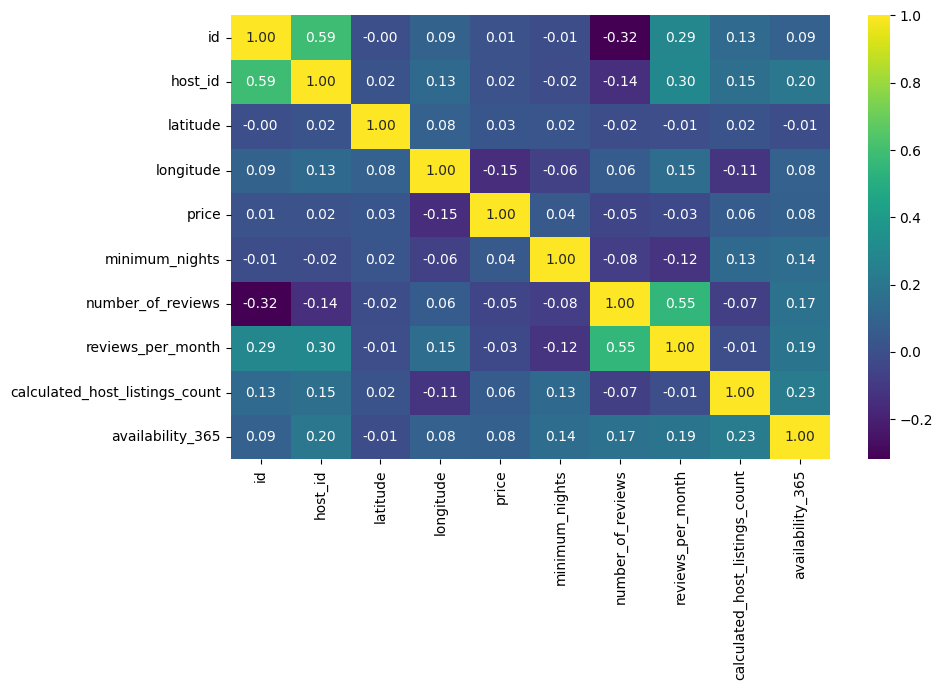

In [18]:
# ESTE HEATMAP NO SE MUY BIEN QUE HACE, ABAJO EXPLICO LA CORRELACIÓN ENTRE POCAS REVIEWS Y EL PRECIO
fig, ax = plt.subplots(figsize=(10, 7))
sns.heatmap(raw_data.select_dtypes(include=['number']).corr(), annot=True, fmt=".2f", cmap="viridis",ax=ax)
plt.tight_layout()
plt.show()

#EXPLICAR CON MIS PALABRAS
Al observar el mapa de calor de correlación, el coeficiente de correlación entre price y number_of_reviews parece estar alrededor de 0.08. Esto indica una correlación positiva muy débil.

En términos más simples:

Correlación positiva débil:
Esto significa que existe una ligera tendencia a que los alojamientos con mayor precio tengan también un número ligeramente mayor de reseñas, y viceversa, pero esta relación no es fuerte. La gran mayoría de la variación en el precio no se explica por el número de reseñas, y es probable que muchos otros factores estén influyendo en ambas variables de forma independiente.

Implicación práctica:
No se puede predecir de manera fiable el precio de un alojamiento basándose únicamente en su número de reseñas, ni al contrario, usando este dataset, debido a que la relación entre ambas variables es muy débil. Otras variables probablemente sean mucho más influyentes para entender el precio.

In [19]:
#LISTA DE TODOS LOS BARRIOS DE NYC, NO SE CÓMO DE ÚTIL PUEDE SER
set(list(raw_data["neighbourhood"]))

{'Allerton',
 'Arden Heights',
 'Arrochar',
 'Arverne',
 'Astoria',
 'Bath Beach',
 'Battery Park City',
 'Bay Ridge',
 'Bay Terrace',
 'Bay Terrace, Staten Island',
 'Baychester',
 'Bayside',
 'Bayswater',
 'Bedford-Stuyvesant',
 'Belle Harbor',
 'Bellerose',
 'Belmont',
 'Bensonhurst',
 'Bergen Beach',
 'Boerum Hill',
 'Borough Park',
 'Breezy Point',
 'Briarwood',
 'Brighton Beach',
 'Bronxdale',
 'Brooklyn Heights',
 'Brownsville',
 "Bull's Head",
 'Bushwick',
 'Cambria Heights',
 'Canarsie',
 'Carroll Gardens',
 'Castle Hill',
 'Castleton Corners',
 'Chelsea',
 'Chinatown',
 'City Island',
 'Civic Center',
 'Claremont Village',
 'Clason Point',
 'Clifton',
 'Clinton Hill',
 'Co-op City',
 'Cobble Hill',
 'College Point',
 'Columbia St',
 'Concord',
 'Concourse',
 'Concourse Village',
 'Coney Island',
 'Corona',
 'Crown Heights',
 'Cypress Hills',
 'DUMBO',
 'Ditmars Steinway',
 'Dongan Hills',
 'Douglaston',
 'Downtown Brooklyn',
 'Dyker Heights',
 'East Elmhurst',
 'East Flatbush